🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Final capstone report (E · read first, run last). Five A3 figures summarising the whole 13-week campaign from the consolidated data.**

---

# 00 · Final Capstone Report — *You Sank My Function*
### The whole campaign on five A3 sheets

**Purpose.** `07_run_week_and_report` answers *"what do I submit this week?"*. This
notebook answers the retrospective question: **what did thirteen weeks of querying
actually achieve, where did the score come from, and what would I do differently?**
It is the front matter of the submission — presented first, run last.

| Figure | What it shows |
|---|---|
| **FR1 · Final scoreboard** | Headline numbers, normalised score per function with ceiling-uncertainty whiskers, and the five findings that carry the report |
| **FR2 · Campaign evolution** | Running best as a fraction of each ceiling, week by week, plus a record ledger showing exactly which queries paid |
| **FR3 · Best-design gallery** | **One landscape panel per function** — a surrogate fitted to that function's own observations, sliced through the winning design along its two most influential coordinates |
| **FR4 · Best designs & evidence** | The winning input vector for all eight functions, and the replicate evidence separating deterministic from noisy |
| **FR5 · Strengths, deviations, lessons** | What worked, what went wrong, and what transfers — every claim measured from the data |

### How this differs from `A3_landscape_gallery`
A3 draws the **hypothesised textbook benchmarks** — Branin, Camelback, Hartmann — from
their published formulas. Several of those identities were later refuted. FR3 here draws
**what our own 279 observations imply**, with the measured points overlaid on top of the
inferred shading, so the picture cannot drift from the evidence. Where A3 says *"this is
the function we think we are facing"*, FR3 says *"this is the function our data describes,
and here is where we ended up in it."*

### Inputs
Reads **`consolidated_observations.csv`** (the output of `04_consolidate_data`) and nothing
else. Ceilings and per-function labels live in one dictionary in §0 — the only judgement
calls in the notebook, and they are surfaced as visible uncertainty whiskers rather than
buried in the arithmetic.

---

## 0 · Configuration

The only hand-set values in the notebook: each function's estimated ceiling (with a plausible `lo`/`hi` range that becomes the uncertainty whisker in FR1) and a short descriptive label. Everything else is derived from the CSV.

> **On F2's ceiling.** F2 is the one function whose true maximum we cannot bound usefully — the seed "best" of 0.6112 was itself an upward draw (its own replicate in Week 3 returned 0.5580). The ceiling is therefore marked *speculative* and F2 is excluded from the headline mean; its bar carries a deliberately wide whisker instead of being silently dropped. The improvement itself is real and is defended in FR1.

In [1]:
import os, textwrap, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle
from matplotlib.colors import BoundaryNorm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
warnings.filterwarnings("ignore")

CSV_PATH = os.environ.get("BBO_CONSOLIDATED_CSV", "consolidated_observations.csv")
OUT_DIR  = os.environ.get("BBO_FIGURE_DIR", ".")   # e.g. "../report/figures"
os.makedirs(OUT_DIR, exist_ok=True)
A3_NOTE = "all figures are A3 landscape (420 x 297 mm)"
A3 = (16.54, 11.69)

FUNCTION_META = {
    1: dict(dim=2, label="log-quadratic crest",  kind="deterministic", story="Model-driven climb to 99.9975% of 2.0"),
    2: dict(dim=2, label="noisy ridge",          kind="noisy",         story="Region switch (high-x2 to low-x2) beat the seed"),
    3: dict(dim=3, label="noisy plateau",        kind="noisy",         story="Explore-don't-redraw banked a high draw"),
    4: dict(dim=4, label="tilted ridge",         kind="deterministic", story="Correlated 4-var step won in the final week"),
    5: dict(dim=4, label="monotone corner",      kind="deterministic", story="Corner (1,1,1,1); x2/x3 permutation symmetry"),
    6: dict(dim=5, label="anisotropic basin",    kind="noisy",         story="Stalled after W3; geometry never recovered"),
    7: dict(dim=6, label="Hartmann-6 (ID'd)",    kind="deterministic", story="Identified W1, analytic optimum locked"),
    8: dict(dim=8, label="separable quadratic",  kind="deterministic", story="Closed form solved exactly in W2"),
}
CEILINGS = {
    1: dict(c=2.0,      lo=2.0,     hi=2.0,     conf="hypothesised"),
    2: dict(c=0.70,     lo=0.66,    hi=0.75,    conf="speculative"),
    3: dict(c=0.0,      lo=-0.005,  hi=0.0,     conf="hard cap"),
    4: dict(c=0.6549,   lo=0.6549,  hi=0.72,    conf="best-ever"),
    5: dict(c=8662.4825,lo=8662.48, hi=8662.49, conf="corner"),
    6: dict(c=-0.2247,  lo=-0.26,   hi=-0.18,   conf="low"),
    7: dict(c=3.3223680114, lo=3.3223680114, hi=3.3223680114, conf="analytic"),
    8: dict(c=10.0,     lo=10.0,    hi=10.0,    conf="analytic"),
}

# palette (house style from 07)
INFO_NAVY="#0d1b3e"; INFO_EDGE="#cfe0f5"; INFO_GREEN="#1f7a3d"; INFO_BLUE="#13357a"
INK="#1b2631"; MUTED="#6b7a90"; TRACK="#eef2f8"; GREY="#566573"
GREEN="#1e8449"; RED="#c0392b"; ORANGE="#ca7a10"; NAVY="#1c3a5e"; NAVY2="#21527d"; PURPLE="#6c3483"
FUNCTION_COLORS={1:"#16a0a0",2:"#8e44ad",3:"#e84b7c",4:"#1f3a93",5:"#ed7d1c",6:"#8c5a2b",7:"#5ba82e",8:"#2e6cc4"}
DARK_BG="#0d1117"; DARK_PANEL="#161b26"; DARK_EDGE="#2b3444"
plt.rcParams.update({"font.family":"DejaVu Sans","axes.edgecolor":"#d5dbdb","figure.dpi":110})

## 1 · Palette, formatting and drawing helpers

Same house style as `07_run_week_and_report` (light infographic panels) and `A3_landscape_gallery` (dark landscape panels), so the final deck reads as one document.

In [2]:
def fmt_score(v):
    if not np.isfinite(v): return "—"
    return f"{v:.5f}" if v>=0.999 else f"{v:.4f}"

def _tint(hexc, amt):
    h=hexc.lstrip("#"); r,g,b=(int(h[k:k+2],16) for k in (0,2,4))
    f=lambda c:int(c+(255-c)*amt); return f"#{f(r):02x}{f(g):02x}{f(b):02x}"

def _ipanel(ax,x,y,w,h,fc="white",ec=INFO_EDGE,lw=1.6,r=1.1,z=1):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={r}",
                 fc=fc,ec=ec,lw=lw,zorder=z))

def _ipill(ax,cx,cy,w,h,text,fc,fs=13,tc="white"):
    ax.add_patch(FancyBboxPatch((cx-w/2,cy-h/2),w,h,
                 boxstyle=f"round,pad=0,rounding_size={h*0.5}",fc=fc,ec="none",zorder=5))
    ax.text(cx,cy,text,ha="center",va="center",color=tc,fontsize=fs,fontweight="bold",zorder=6)

def _wrapped(ax,x,y,text,width_chars,fs=9.3,color=INK,weight="normal",leading=0.034,va="top"):
    for i,ln in enumerate(textwrap.wrap(text,width=width_chars)):
        ax.text(x,y-i*leading,ln,fontsize=fs,color=color,fontweight=weight,va=va,ha="left")

## 2 · Data layer

Everything the report claims is computed here: per-function baseline, best, winning design, which weeks set records, normalised score, replicate pairs and the noise implied by them. No figure holds its own copy of a number.

In [3]:
def load_obs(path=CSV_PATH):
    df=pd.read_csv(path)
    df["function"]=df["function"].astype(int); df["week"]=df["week"].astype(int)
    return df

def xcols(f): return [f"x{i}" for i in range(1,FUNCTION_META[f]["dim"]+1)]

def fn_frame(df,f):
    sub=df[df.function==f].copy()
    return sub[["week","source"]+xcols(f)+["y"]].reset_index(drop=True)

def campaign_table(df):
    rows=[]
    for f in range(1,9):
        sub=fn_frame(df,f); cols=xcols(f)
        w0=sub[sub.week==0]; wk=sub[sub.week>0].sort_values("week")
        init=float(w0.y.max())
        allrows=pd.concat([w0,wk]); i=allrows.y.idxmax()
        best=float(allrows.loc[i,"y"]); bx=allrows.loc[i,cols].to_numpy(float)
        # earliest week that reached the best (16-digit ties on deterministic functions)
        tol=max(1e-12,1e-9*abs(best))
        hit=allrows[allrows.y>=best-tol]
        bw=int(hit.week.min())
        j=hit[hit.week==bw].index[0]; bx=allrows.loc[j,cols].to_numpy(float)
        run=init; recs=[]
        for _,r in wk.iterrows():
            if r.y>run: recs.append(int(r.week)); run=float(r.y)
        c=CEILINGS[f]; den=c["c"]-init
        score=float(np.clip((best-init)/den,0,1)) if abs(den)>1e-12 else np.nan
        def sc(cc):
            d=cc-init
            return float(np.clip((best-init)/d,0,1)) if abs(d)>1e-12 else np.nan
        rows.append(dict(f=f,dim=FUNCTION_META[f]["dim"],kind=FUNCTION_META[f]["kind"],
                         label=FUNCTION_META[f]["label"],story=FUNCTION_META[f]["story"],
                         init_best=init,best=best,best_week=bw,best_x=bx,
                         gain=best-init,n_records=len(recs),record_weeks=recs,
                         score=score,score_lo=min(sc(c["lo"]),sc(c["hi"])),
                         score_hi=max(sc(c["lo"]),sc(c["hi"])),ceil=c["c"],ceil_conf=c["conf"],
                         n_obs=len(sub)))
    return pd.DataFrame(rows)

def running_best_series(df,f):
    sub=fn_frame(df,f)
    init=float(sub[sub.week==0].y.max())
    out={0:init}; run=init
    for _,r in sub[sub.week>0].sort_values("week").iterrows():
        run=max(run,float(r.y)); out[int(r.week)]=run
    return pd.Series(out).sort_index()

def replicate_audit(df,tol=4):
    recs=[]
    for f in range(1,9):
        sub=fn_frame(df,f); cols=xcols(f)
        key=sub[cols].round(tol).apply(tuple,axis=1)
        for k,g in sub.groupby(key):
            if len(g)>1:
                y=g.y.to_numpy(float)
                recs.append(dict(f=f,weeks=list(g.week),n=len(g),spread=float(y.max()-y.min()),
                                 y_mean=float(y.mean())))
    return pd.DataFrame(recs)

def noise_estimates(df):
    """Pooled sigma per function from exact replicate pairs (0 => deterministic)."""
    rep=replicate_audit(df); out={}
    for f in range(1,9):
        r=rep[rep.f==f]
        if len(r)==0: out[f]=np.nan; continue
        sp=r.spread.to_numpy()
        out[f]=float(np.sqrt(np.mean(sp**2)/2)) if sp.max()>1e-9 else 0.0
    return out

In [4]:
df  = load_obs()
tab = campaign_table(df)

print(f"{len(df)} observations · {int((df.week>0).sum())} weekly queries · "
      f"{int(tab.n_records.sum())} records set\n")
show = tab[["f","dim","kind","init_best","best","best_week","gain","n_records","score"]].copy()
show.columns = ["F","dim","kind","Week-0 best","final best","found","gain","records","score"]
display(show.style.format({"Week-0 best":"{:.6g}","final best":"{:.6g}",
                           "gain":"{:.6g}","score":"{:.5f}"}).hide(axis="index"))

279 observations · 104 weekly queries · 33 records set



F,dim,kind,Week-0 best,final best,found,gain,records,score
1,2,deterministic,7.71088e-16,1.99995,11,1.99995,7,0.99998
2,2,noisy,0.611205,0.650484,10,0.0392792,2,0.44236
3,3,noisy,-0.0348353,-0.000369921,12,0.0344654,4,0.98938
4,4,deterministic,-4.02554,0.654868,13,4.68041,6,0.99999
5,4,deterministic,1088.86,8662.48,9,7573.62,6,1.00000
6,5,noisy,-0.714265,-0.234747,10,0.479518,3,0.97948
7,6,deterministic,1.36497,3.32237,1,1.9574,3,1.00000
8,8,deterministic,9.59848,10,2,0.401518,2,1.00000


In [5]:
# Replicate audit — the single most informative measurement type of the campaign
rep = replicate_audit(df)
print("Repeated inputs (same x queried more than once):")
display(rep)
print("Implied noise sigma per function (0.0 = deterministic to machine precision):")
for f, s in noise_estimates(df).items():
    print(f"  F{f}: " + ("no replicate — noise never measured" if not np.isfinite(s)
                          else ("deterministic" if s == 0 else f"sigma ~ {s:.4f}")))

Repeated inputs (same x queried more than once):


,f,weeks,n,spread,y_mean
0,1,"[11, 13]",2,0.000000e+00,1.999950
1,2,"[0, 3]",2,5.321143e-02,0.584600
2,3,"[1, 2]",2,6.888733e-03,-0.028361
3,3,"[12, 13]",2,2.500138e-02,-0.012871
4,5,"[9, 13]",2,0.000000e+00,8662.482500
5,7,"[1, 2]",2,2.643086e-11,3.322368
6,7,"[3, 6, 7, 8, 10, 11, 12, 13]",8,7.535039e-11,3.322368
7,8,"[2, 6, 7, 8, 9, 10, 11, 12, 13]",9,2.499991e-10,10.000000


Implied noise sigma per function (0.0 = deterministic to machine precision):
  F1: deterministic
  F2: sigma ~ 0.0376
  F3: sigma ~ 0.0130
  F4: no replicate — noise never measured
  F5: deterministic
  F6: no replicate — noise never measured
  F7: deterministic
  F8: deterministic


## 3 · Figure FR1 — Final scoreboard

The cover sheet. Normalised score `(best − Week-0 baseline) / (ceiling − Week-0 baseline)`, clipped to [0, 1], with whiskers spanning the score implied by each ceiling's `lo`/`hi`. A wide whisker is an honest admission that the *ceiling*, not the search, is the dominant source of score error.

In [6]:
def fig_cover(df,tab,save=None):
    n_obs=len(df); n_q=int((df.week>0).sum()); n_rec=int(tab.n_records.sum())
    scorable=tab[np.isfinite(tab.score) & (tab.f!=2)]   # F2's ceiling is speculative
    W,H=A3; YT=100*H/W
    fig=plt.figure(figsize=A3); fig.patch.set_facecolor("white")
    bg=fig.add_axes([0,0,1,1]); bg.set_xlim(0,100); bg.set_ylim(0,YT); bg.axis("off")
    _ipanel(bg,2,62.0,96,7.2,fc=INFO_NAVY,ec="none",r=1.3)
    bg.text(50,66.6,"YOU SANK MY FUNCTION  ·  FINAL CAMPAIGN SCOREBOARD",ha="center",va="center",
            color="white",fontsize=23,fontweight="bold")
    bg.text(50,63.8,f"{n_obs} observations · 8 unknown functions · {n_q} weekly queries over 13 rounds",
            ha="center",va="center",color="#f4b942",fontsize=12.5,style="italic")
    # KPI strip
    kpis=[(f"{n_q}","queries spent","#13357a"),
          (f"{n_rec}","new records set","#1f7a3d"),
          (f"{n_rec/n_q:.0%}","query hit rate","#8e44ad"),
          (f"{scorable.score.mean():.4f}","mean score (7 scored)",'#c0392b'),
          ("4 / 8","at a proven optimum","#ca7a10")]
    gap=1.6; x0=2.0; cw=(96-gap*(len(kpis)-1))/len(kpis)
    for k,(big,lab,col) in enumerate(kpis):
        x=x0+k*(cw+gap)
        _ipanel(bg,x,52.0,cw,8.6,fc=_tint(col,0.90),ec=_tint(col,0.55),lw=1.5,r=0.9)
        bg.text(x+cw/2,57.6,big,ha="center",va="center",color=col,fontsize=25,fontweight="bold")
        bg.text(x+cw/2,54.0,lab.upper(),ha="center",va="center",color=MUTED,fontsize=9.5,fontweight="bold")
    # left: score bars
    _ipanel(bg,2,10.0,58,40.0); _ipill(bg,20,48.3,32,2.7,"Score vs estimated ceiling",INFO_BLUE,fs=12.5)
    ax=fig.add_axes([8.5/100,13.5/YT,47/100,30.5/YT]); ax.set_facecolor("none")
    order=list(tab.sort_values("score",na_position="first").f)
    yy=np.arange(8)
    for s in ax.spines.values(): s.set_visible(False)
    ax.barh(yy,1.0,height=0.55,color=TRACK,zorder=1)
    for k,f in enumerate(order):
        r=tab[tab.f==f].iloc[0]; v=r["score"]
        if np.isfinite(v):
            ax.barh(k,v,height=0.55,color=FUNCTION_COLORS[f],zorder=2)
            lo,hi=r["score_lo"],r["score_hi"]
            if np.isfinite(lo) and hi-lo>0.005:
                ax.plot([lo,hi],[k,k],color="#33405a",lw=1.5,zorder=4)
                for xc in (lo,hi): ax.plot([xc,xc],[k-0.14,k+0.14],color="#33405a",lw=1.5,zorder=4)
            ax.text(max(v,hi if np.isfinite(hi) else v)+0.02,k,fmt_score(v),va="center",ha="left",
                    fontsize=10,fontweight="bold",color=FUNCTION_COLORS[f])
        else:
            ax.text(0.02,k,"not scored — denominator degenerate",va="center",ha="left",
                    fontsize=9,style="italic",color=GREY)
    ax.set_xlim(0,1.18); ax.set_ylim(-0.6,7.5)
    ax.set_yticks(yy); ax.set_yticklabels([f"F{f}" for f in order],fontsize=12,fontweight="bold")
    for t,f in zip(ax.get_yticklabels(),order): t.set_color(FUNCTION_COLORS[f])
    ax.set_xticks(np.linspace(0,1,6)); ax.tick_params(length=0,labelsize=9)
    ax.set_xlabel("(best − Week-0 baseline) / (ceiling − Week-0 baseline)",fontsize=9.5,color=MUTED,labelpad=6)
    ax.grid(axis="x",color="#eef2f8",lw=1)
    # right: headline findings
    _ipanel(bg,62.5,10.0,35.5,40.0); _ipill(bg,80.2,48.3,24,2.7,"HEADLINE FINDINGS",INFO_GREEN,fs=12.5)
    f4=tab[tab.f==4].iloc[0]; f1=tab[tab.f==1].iloc[0]; f5=tab[tab.f==5].iloc[0]
    items=[(7,"Two functions solved in algebra, not search",
            "F7 identified as Hartmann-6 in Week 1, F8 as a separable quadratic in Week 2 — both locked at analytic maxima and free from then on."),
           (1,"F1 climbed to 99.9975% of 2.0",
            f"Four consecutive successful extrapolations of a log-quadratic crest model took it from 0.93 to {f1['best']:.6f}."),
           (4,"F4's win came from a correlated step",
            f"The Week-13 move changed all four coordinates at once and set the record at {f4['best']:.4f} — an axis-aligned probe could not have found it."),
           (5,"F5's corner was worth 2x",
            f"x1 was held below 0.09 for seven weeks; the first probe at the far end returned {f5['best']:.0f}."),
           (2,"F2 improved, and it was not luck",
            "The final low-x2 region reads 0.639 +/- 0.016 across four visits, ~3 sigma above the seed region whose own replicate fell to 0.558.")]
    iy=44.5
    for f,lead,detail in items:
        bg.add_patch(FancyBboxPatch((64.4,iy-0.55),1.1,1.1,boxstyle="round,pad=0,rounding_size=0.35",
                     fc=FUNCTION_COLORS[f],ec="none",zorder=4))
        bg.text(66.4,iy,lead,fontsize=10.6,fontweight="bold",va="center",color=INK,zorder=4)
        bg.text(66.4,iy-1.5,textwrap.fill(detail,42),fontsize=8.6,va="top",color="#41506a",
                zorder=4,linespacing=1.3)
        iy-=7.6
    # footer strip
    _ipanel(bg,2,0.8,96,7.6,fc=INFO_NAVY,ec="none",r=1.0)
    gap=1.0; cw=(94-gap*7)/8
    for i in range(8):
        f=i+1; r=tab[tab.f==f].iloc[0]; x=3.0+i*(cw+gap); c=FUNCTION_COLORS[f]
        _ipanel(bg,x,1.6,cw,6.0,fc=_tint(c,0.80),ec="none",r=0.7,z=3)
        cx=x+cw/2
        bg.text(cx,6.4,f"F{f}",ha="center",color=c,fontsize=13,fontweight="bold",zorder=4)
        bg.text(cx,4.6,f"{r['best']:.6g}",ha="center",color=INK,fontsize=11.5,fontweight="bold",zorder=4)
        s=fmt_score(r["score"])
        bg.text(cx,2.6,f"{r['dim']}D · score {s}",ha="center",color=c,fontsize=7.6,fontweight="bold",zorder=4)
    if save: fig.savefig(save,dpi=140,bbox_inches="tight",facecolor="white",pad_inches=0.12)
    return fig

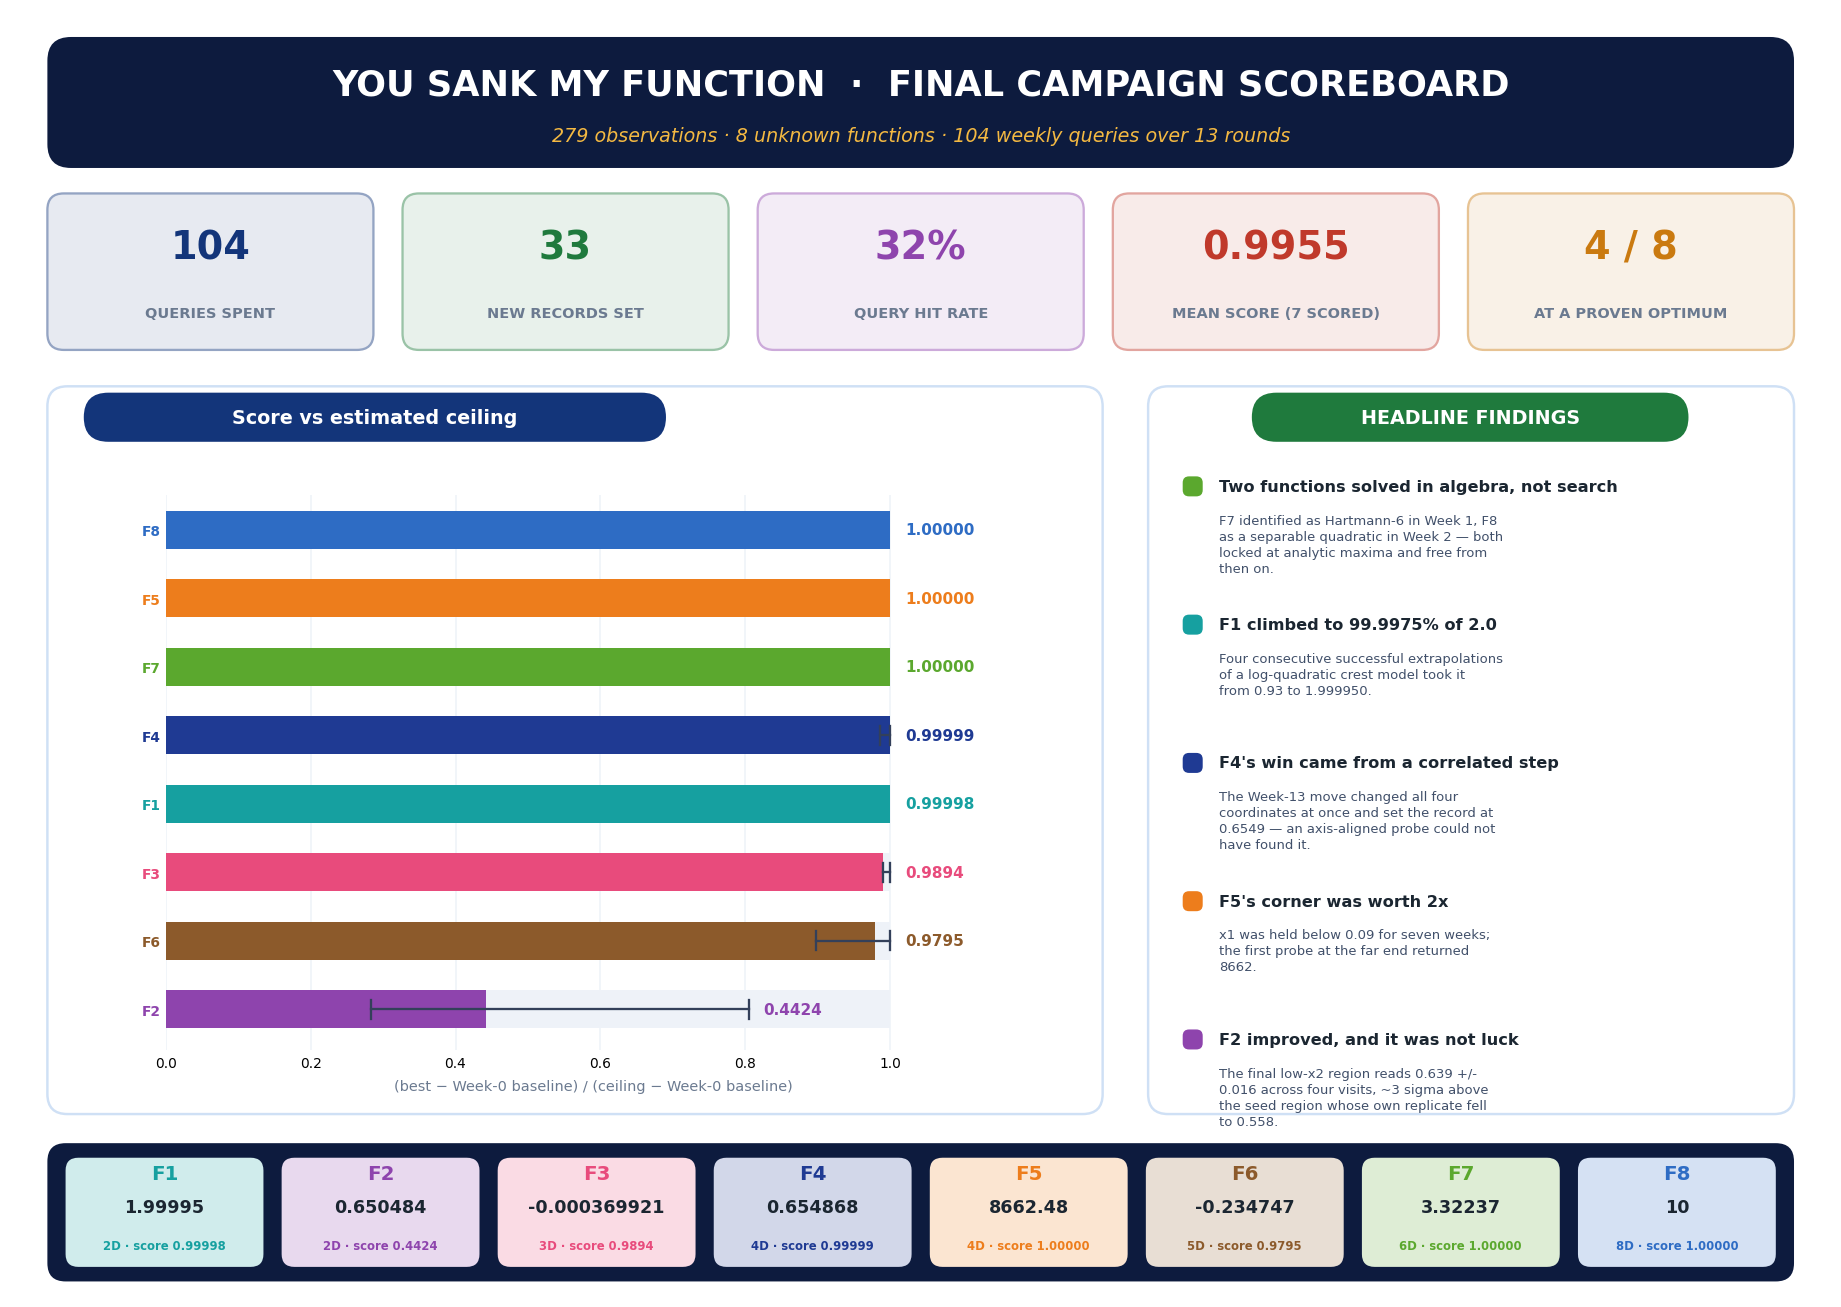

In [7]:
fig_cover(df, tab, save=f"{OUT_DIR}/FR1_final_scoreboard.png");

## 4 · Figure FR2 — Campaign evolution

Raw outputs are incomparable across functions spanning 10⁻³ to 10³, so each function is plotted as the **fraction of its own ceiling reached**. On that axis a flat line means a wasted week regardless of scale. The ledger beside it marks every query that beat the running best.

In [8]:
def fig_evolution(df,tab,save=None):
    W,H=A3; YT=100*H/W
    fig=plt.figure(figsize=A3); fig.patch.set_facecolor("white")
    bg=fig.add_axes([0,0,1,1]); bg.set_xlim(0,100); bg.set_ylim(0,YT); bg.axis("off")
    _ipanel(bg,2,63.0,96,6.0,fc=INFO_NAVY,ec="none",r=1.3)
    bg.text(50,66.6,"FIGURE FR2  ·  CAMPAIGN EVOLUTION",ha="center",va="center",color="white",
            fontsize=21,fontweight="bold")
    bg.text(50,64.2,"Running best as a fraction of the ceiling, week by week — where the score was actually won",
            ha="center",va="center",color="#f4b942",fontsize=11.5,style="italic")
    # main: normalised progress curves
    _ipanel(bg,2,20.5,63,41.0); _ipill(bg,20,59.2,32,2.7,"Progress to ceiling",INFO_BLUE,fs=12.5)
    ax=fig.add_axes([9/100,24/YT,53/100,31.5/YT]); ax.set_facecolor("none")
    ends={}
    for f in range(1,9):
        r=tab[tab.f==f].iloc[0]; s=running_best_series(df,f)
        den=r["ceil"]-r["init_best"]
        prog=(s-r["init_best"])/den if abs(den)>1e-12 else pd.Series(np.nan,index=s.index)
        prog=prog.clip(0,1)
        ax.plot(s.index,prog,color=FUNCTION_COLORS[f],lw=2.2,marker="o",ms=3.6,zorder=3)
        ends[f]=float(prog.iloc[-1])
    # de-overlap the end labels
    order=sorted(ends,key=lambda k:ends[k]); placed={}; last=-9.0
    for f in order:
        v=max(ends[f],last+0.035); placed[f]=v; last=v
    for f,v in placed.items():
        ax.text(13.2,v,f"F{f}",color=FUNCTION_COLORS[f],fontsize=9,fontweight="bold",va="center")
    ax.set_xlim(-0.4,13.9); ax.set_ylim(-0.04,1.06)
    ax.set_xticks(range(0,14)); ax.set_xticklabels([f"W{w}" for w in range(14)],fontsize=8.4)
    ax.set_yticks(np.linspace(0,1,6)); ax.tick_params(labelsize=9)
    for s_ in ("top","right"): ax.spines[s_].set_visible(False)
    ax.spines["left"].set_color("#cbd5e6"); ax.spines["bottom"].set_color("#cbd5e6")
    ax.grid(axis="y",color="#eef2f8",lw=1)
    ax.set_xlabel("round",fontsize=10,color=MUTED); ax.set_ylabel("fraction of ceiling reached",fontsize=10,color=MUTED)
    # right: record ledger
    _ipanel(bg,67.5,20.5,30.5,41.0); _ipill(bg,82.7,59.2,24,2.7,"RECORD LEDGER",INFO_GREEN,fs=12.5)
    bg.text(69.5,56.2,"F",fontsize=9,fontweight="bold",color=NAVY)
    bg.text(72.4,56.2,"records",fontsize=9,fontweight="bold",color=NAVY)
    bg.text(80.0,56.2,"weeks they landed",fontsize=9,fontweight="bold",color=NAVY)
    yy=53.0
    for f in range(1,9):
        r=tab[tab.f==f].iloc[0]; c=FUNCTION_COLORS[f]
        bg.text(69.5,yy,f"F{f}",fontsize=10.5,fontweight="bold",color=c,va="center")
        bg.text(73.6,yy,f"{r['n_records']}/13",fontsize=9.6,color=INK,va="center",ha="center")
        for w in range(1,14):
            xx=78.0+(w-1)*1.45
            hit=w in r["record_weeks"]
            bg.add_patch(Rectangle((xx,yy-0.58),1.08,1.16,fc=c if hit else "#e9eef6",ec="none",zorder=4))
        yy-=3.25
    bg.text(78.0,yy+1.3,"W1",fontsize=6.8,color=MUTED)
    bg.text(96.0,yy+1.3,"W13",fontsize=6.8,color=MUTED,ha="right")
    n_rec=int(tab.n_records.sum()); n_q=int((df.week>0).sum())
    bg.text(69.5,yy-0.6,textwrap.fill(
        f"Filled cell = that week's query beat the running best. {n_rec} of {n_q} queries set a "
        "record — a hit rate that follows from model-driven rather than random proposals.",44),
        fontsize=8.5,color="#41506a",va="top",linespacing=1.45)
    # bottom: phase strip
    _ipanel(bg,2,2.0,96,16.5)
    _ipill(bg,15,17.0,26,2.7,"Three phases of the campaign",INFO_BLUE,fs=12.5)
    phases=[("W1–W3  ·  IDENTIFY","#13357a",
             "F7 recovered as Hartmann-6 (residual 4.4e-16) and F8 solved in closed form. Two functions leave the budget permanently."),
            ("W4–W9  ·  EXPLOIT","#1f7a3d",
             "F1's crest model compounds; F5's corner finally found in W9 after seven weeks pinned at low x1; F6 stalls after its W3 jump."),
            ("W10–W13  ·  REFINE & VERIFY","#8e44ad",
             "F1 closes to 5e-05 of 2.0, F4 breaks its record in the final week, and exact replicates confirm determinism to 16 digits.")]
    gap=2.0; cw=(92-gap*2)/3
    for k,(t,c,b) in enumerate(phases):
        x=4.0+k*(cw+gap)
        _ipanel(bg,x,3.4,cw,10.2,fc=_tint(c,0.92),ec=_tint(c,0.6),lw=1.4,r=0.8,z=3)
        bg.text(x+1.5,11.8,t,fontsize=11,fontweight="bold",color=c,va="center",zorder=4)
        bg.text(x+1.5,10.2,textwrap.fill(b,52),fontsize=8.8,color="#41506a",va="top",zorder=4,linespacing=1.35)
    if save: fig.savefig(save,dpi=140,bbox_inches="tight",facecolor="white",pad_inches=0.12)
    return fig

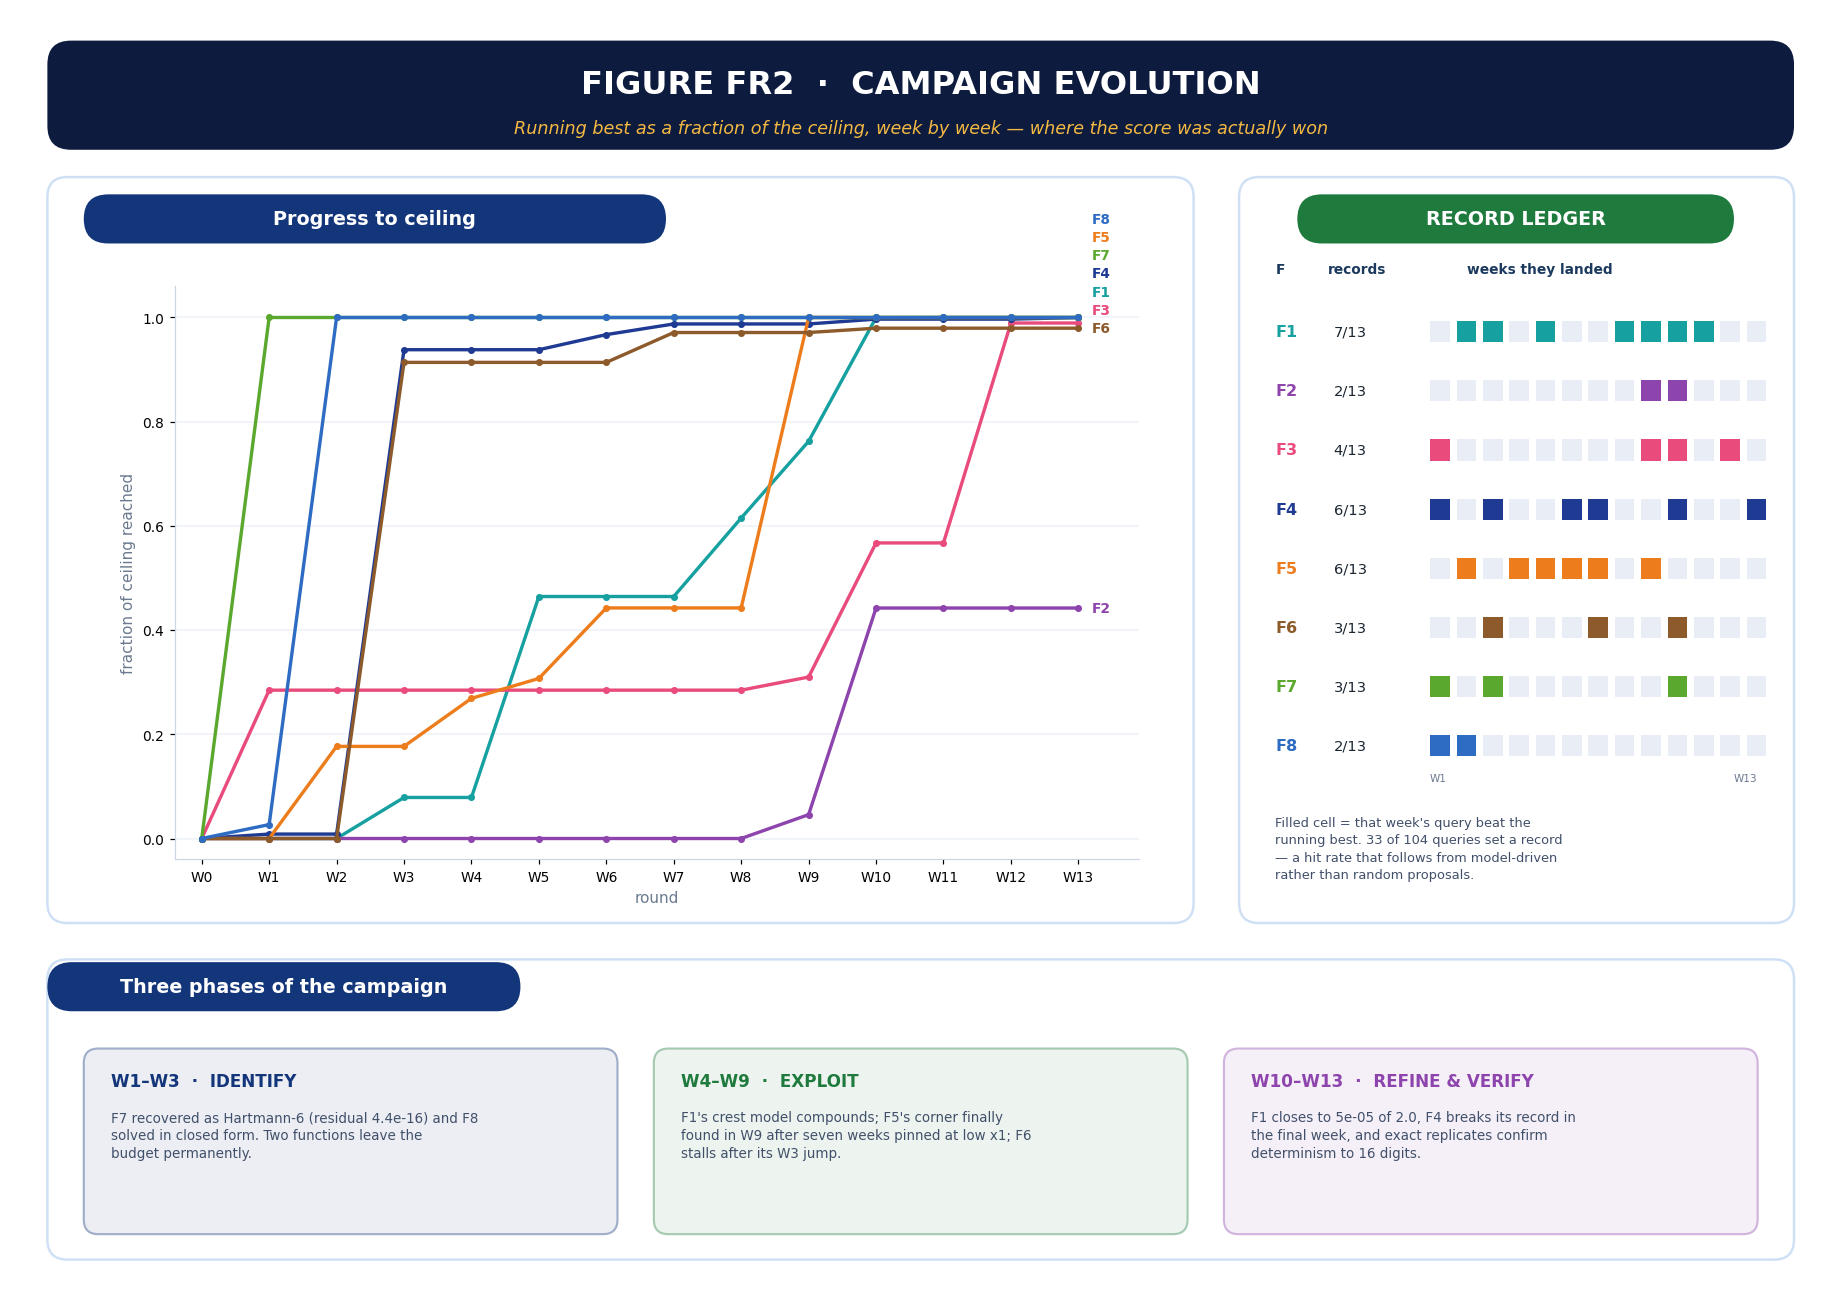

In [9]:
fig_evolution(df, tab, save=f"{OUT_DIR}/FR2_campaign_evolution.png");

## 5 · Figure FR3 — Best-design gallery *(the centrepiece)*

One panel per function showing **where the winning design sits in its own landscape**.

**How each panel is built.**
1. A Gaussian-process surrogate is fitted to *that function's* observations. `y` is
   **rank-normalised** first, so a spiky function (F1 spans 10⁻⁷⁹ to 2) and a large-scale
   one (F5 spans 0.1 to 8662) are both fittable with the same kernel and both legible with
   the same colour map.
2. The two coordinates the surrogate is **most sensitive to at the optimum** are chosen by
   sweeping each axis through the winning design and measuring the response — a data-driven
   choice rather than a guessed pair.
3. The remaining coordinates are pinned at the winning design, so the panel is the slice
   that actually passes through our best point.
4. Every observation is projected onto the slice; **the fainter a circle, the further it
   sits from the slice** in the pinned coordinates. The star is the winning design.

> **Read it honestly.** The stars and circles are measured. The shading between them is
> inference from a model fitted to at most a few dozen points in up to eight dimensions —
> it shows the *shape our data implies*, not ground truth. F6's near-empty panel is the
> point: after thirteen queries its local geometry is still barely constrained.

In [10]:
def fit_surrogate(df,f,alpha_noise=None):
    sub=fn_frame(df,f); cols=xcols(f)
    X=sub[cols].to_numpy(float); y=sub.y.to_numpy(float)
    # rank-normalise y so wildly-scaled functions (F5) and spiky ones (F1) both fit
    r=pd.Series(y).rank(method="average").to_numpy()
    z=(r-r.mean())/(r.std()+1e-12)
    if alpha_noise is None:
        alpha_noise=1e-6 if FUNCTION_META[f]["kind"]=="deterministic" else 1e-2
    k=ConstantKernel(1.0,(1e-2,1e3))*Matern(length_scale=np.full(X.shape[1],0.3),
        length_scale_bounds=(0.03,3.0),nu=2.5)+WhiteKernel(1e-3,(1e-8,1e0))
    gp=GaussianProcessRegressor(kernel=k,alpha=alpha_noise,normalize_y=True,
                                n_restarts_optimizer=2,random_state=0).fit(X,z)
    return gp,X,y

def top2_dims(gp,xstar,d,n=41):
    """Data-driven pick of the two most influential coordinates at the optimum."""
    g=np.linspace(0,1,n); sens=[]
    for i in range(d):
        P=np.tile(xstar,(n,1)); P[:,i]=g
        sens.append(float(gp.predict(P).std()))
    order=np.argsort(sens)[::-1]
    return int(order[0]),int(order[1]),np.array(sens)

In [11]:
def fig_best_design_gallery(df,tab,save=None,n=70):
    fig=plt.figure(figsize=A3); fig.patch.set_facecolor(DARK_BG)
    fig.suptitle("FIGURE FR3  ·  BEST DESIGN GALLERY — where each optimum sits in its own landscape",
                 color="white",fontsize=19,fontweight="bold",y=0.982)
    fig.text(0.5,0.945,"Data-driven GP surrogate fitted to each function's own observations · "
             "slice through the best design along its two most influential coordinates · "
             "★ best design   ○ observations (fainter = further from the slice)",
             ha="center",color="#f4b942",fontsize=10.5,style="italic")
    gs=fig.add_gridspec(2,4,left=0.045,right=0.985,top=0.885,bottom=0.085,hspace=0.34,wspace=0.26)
    g=np.linspace(0,1,n); G1,G2=np.meshgrid(g,g)
    info={}
    for idx in range(8):
        f=idx+1; row=tab[tab.f==f].iloc[0]; d=row["dim"]; xs=row["best_x"]
        ax=fig.add_subplot(gs[idx//4,idx%4]); ax.set_facecolor(DARK_BG)
        gp,X,y=fit_surrogate(df,f)
        i,j,sens=top2_dims(gp,xs,d)
        i,j=(i,j) if i<j else (j,i)          # keep the lower-index coordinate on the x-axis
        P=np.tile(xs,(n*n,1)); P[:,i]=G1.ravel(); P[:,j]=G2.ravel()
        Z=gp.predict(P).reshape(n,n)
        lv=np.unique(np.quantile(Z,np.linspace(0,1,26)))
        if len(lv)<3: lv=np.linspace(Z.min(),Z.max(),4)
        ax.contourf(G1,G2,Z,levels=lv,cmap="plasma")
        ax.contour(G1,G2,Z,levels=lv[::4],colors="white",alpha=0.16,linewidths=0.5)
        # observations projected, faded by distance in the pinned coordinates
        pin=[k for k in range(d) if k not in (i,j)]
        dist=np.linalg.norm(X[:,pin]-xs[pin],axis=1)/max(1,np.sqrt(len(pin))) if pin else np.zeros(len(X))
        al=np.clip(1.0-dist/0.5,0.12,0.95)
        ec=np.zeros((len(X),4)); ec[:,:3]=1.0; ec[:,3]=al
        ax.scatter(X[:,i],X[:,j],s=17,facecolor="none",edgecolors=ec,
                   linewidths=0.8,zorder=4)
        ax.plot(xs[i],xs[j],"*",color="cyan",ms=19,mec="white",mew=1.4,zorder=6,clip_on=False)
        ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)
        ax.set_title(f"F{f} — {row['label']}\nbest {row['best']:.6g}  ·  week {row['best_week']}",
                     color="white",fontsize=10.5,fontweight="bold",pad=7)
        ax.set_xlabel(f"x{i+1}",color="#aaaaaa",fontsize=9); ax.set_ylabel(f"x{j+1}",color="#aaaaaa",fontsize=9)
        ax.tick_params(colors="#aaaaaa",labelsize=7.5)
        for s in ax.spines.values(): s.set_edgecolor("#333c4d")
        note=(f"slice: x{i+1}×x{j+1}" if d==2 else
              f"slice x{i+1}×x{j+1} · {d-2} pinned at x*")
        ax.text(0.03,0.965,note,transform=ax.transAxes,color="#ffaa00",fontsize=7,va="top",
                bbox=dict(boxstyle="round,pad=0.22",facecolor="#1a1a2e",alpha=0.85))
        # park the x* caption in whichever bottom corner is further from the star
        xa,ha_=(0.97,"right") if xs[i]<0.5 else (0.03,"left")
        ax.text(xa,0.03,f"x*={np.array2string(xs,precision=3,separator=',')[1:-1]}",
                transform=ax.transAxes,color="#cfe0f5",fontsize=6.4,ha=ha_,va="bottom",
                bbox=dict(boxstyle="round,pad=0.22",facecolor="#1a1a2e",alpha=0.85))
        info[f]=(i,j,sens)
    fig.text(0.5,0.022,"Colour is rank-normalised (equal-count contour bands) so spiky F1 and "
             "large-scale F5 are equally legible; brighter = better. The surrogate is illustrative — "
             "the stars and circles are measured, the shading between them is inference.",
             ha="center",color="#8fa3c0",fontsize=9.5,style="italic")
    if save: fig.savefig(save,dpi=140,bbox_inches="tight",facecolor=DARK_BG)
    return fig,info

Slice chosen per function (most influential pair at the optimum):
  F1: x1 x2   sensitivity by coordinate = x1=0.30, x2=0.37
  F2: x1 x2   sensitivity by coordinate = x1=0.64, x2=0.14
  F3: x2 x3   sensitivity by coordinate = x1=0.01, x2=0.71, x3=0.63
  F4: x2 x3   sensitivity by coordinate = x1=0.52, x2=0.60, x3=0.63, x4=0.48
  F5: x3 x4   sensitivity by coordinate = x1=0.17, x2=0.31, x3=0.52, x4=0.46
  F6: x1 x5   sensitivity by coordinate = x1=0.55, x2=0.13, x3=0.12, x4=0.54, x5=0.57
  F7: x4 x5   sensitivity by coordinate = x1=0.24, x2=0.43, x3=0.02, x4=0.57, x5=0.71, x6=0.48
  F8: x1 x3   sensitivity by coordinate = x1=0.42, x2=0.15, x3=0.58, x4=0.08, x5=0.12, x6=0.03, x7=0.27, x8=0.02


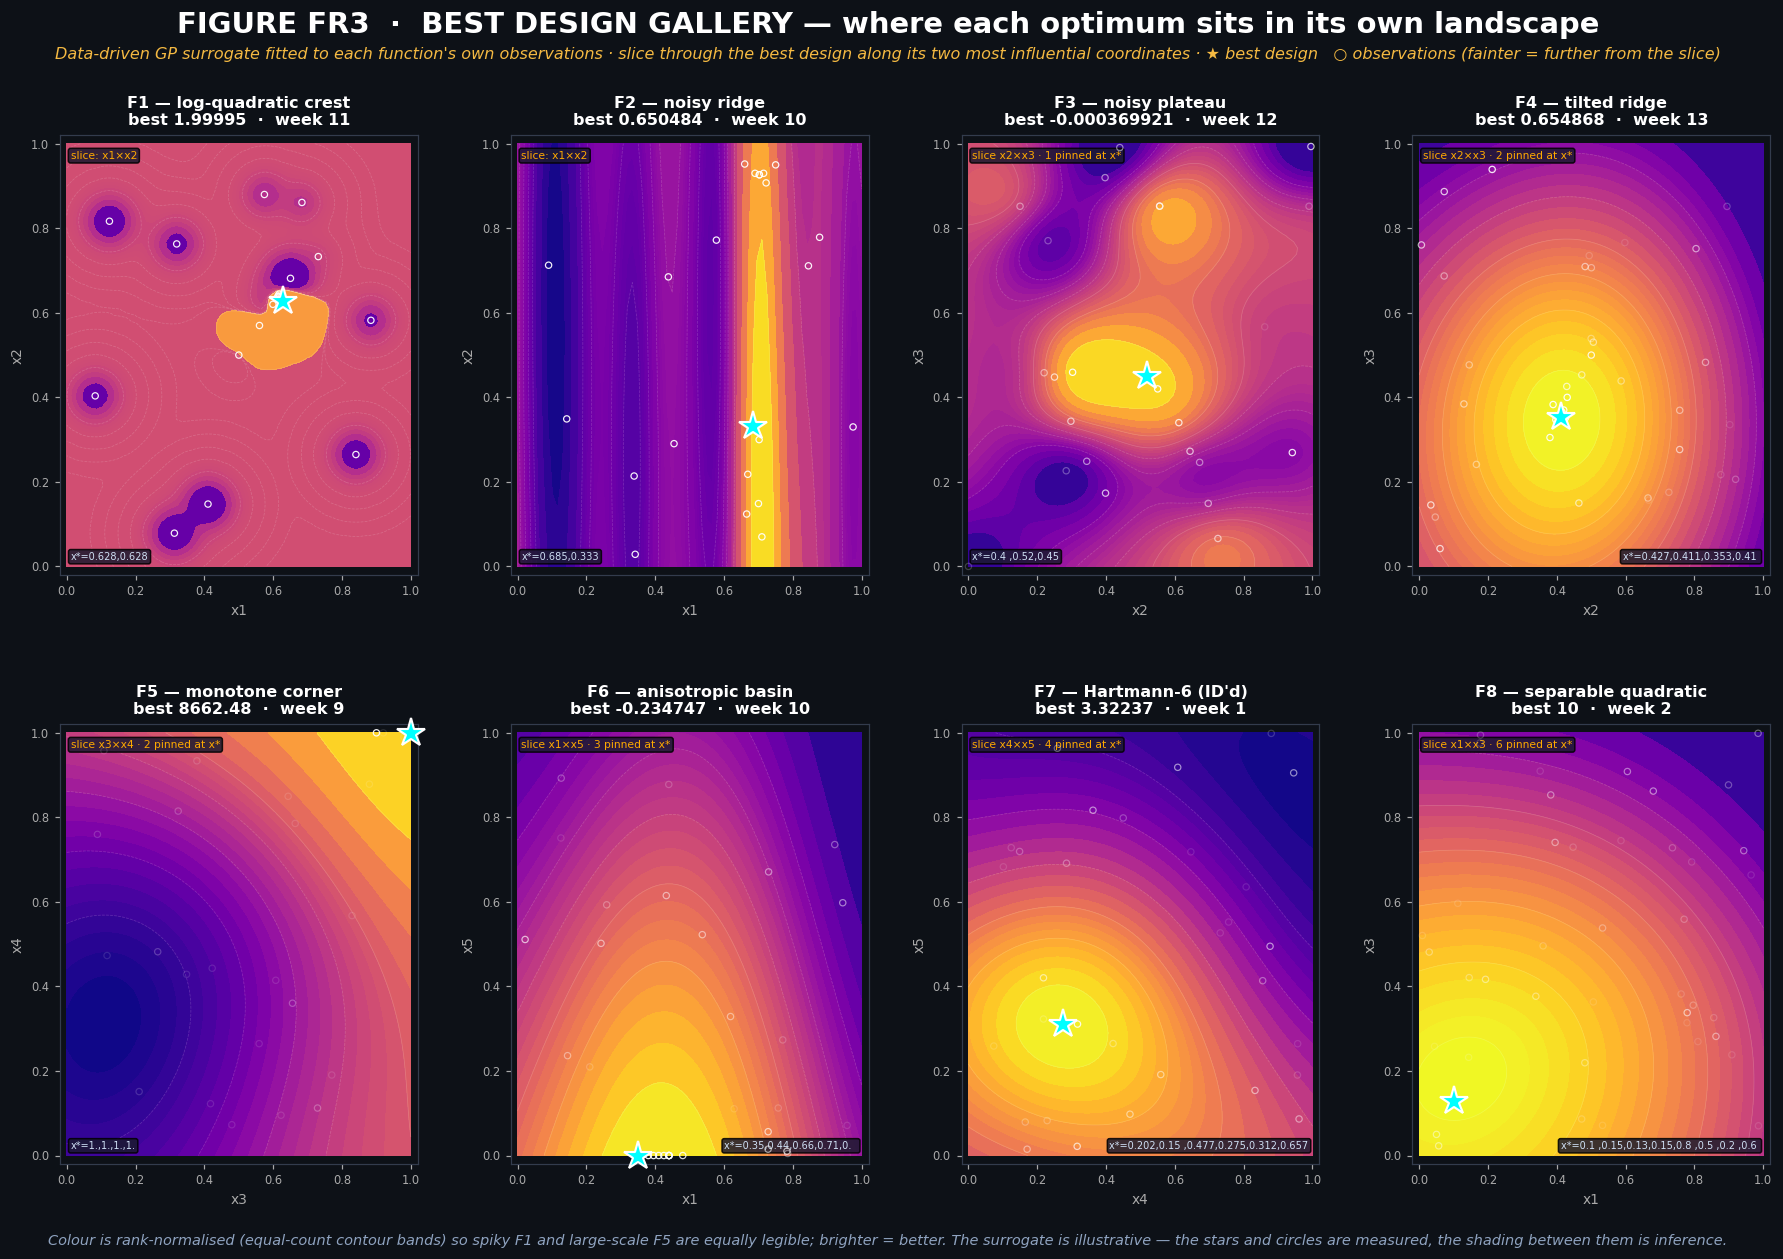

In [12]:
fig, slices = fig_best_design_gallery(df, tab, save=f"{OUT_DIR}/FR3_best_design_gallery.png")
print("Slice chosen per function (most influential pair at the optimum):")
for f, (i, j, sens) in slices.items():
    print(f"  F{f}: x{i+1} x{j+1}   sensitivity by coordinate = "
          + ", ".join(f"x{k+1}={v:.2f}" for k, v in enumerate(sens)))

## 6 · Figure FR4 — Best designs and the evidence behind them

The deliverable itself — the winning input vector for every function — beside the replicate evidence that tells us how much to trust each one. The lower-left panel is the cheapest diagnostic of the whole campaign and the one we ran least: repeat an input, and the spread tells you immediately whether you are optimising a surface or chasing noise.

In [13]:
def fig_designs_and_evidence(df,tab,save=None):
    rep=replicate_audit(df); sig=noise_estimates(df)
    W,H=A3; YT=100*H/W
    fig=plt.figure(figsize=A3); fig.patch.set_facecolor("white")
    bg=fig.add_axes([0,0,1,1]); bg.set_xlim(0,100); bg.set_ylim(0,YT); bg.axis("off")
    _ipanel(bg,2,63.0,96,6.0,fc=INFO_NAVY,ec="none",r=1.3)
    bg.text(50,66.6,"FIGURE FR4  ·  BEST DESIGNS AND THE EVIDENCE BEHIND THEM",ha="center",va="center",
            color="white",fontsize=20,fontweight="bold")
    bg.text(50,64.2,"The winning input vector for every function, and the replicate evidence that "
            "separates the deterministic ones from the noisy ones",
            ha="center",va="center",color="#f4b942",fontsize=11,style="italic")
    # A · parallel coordinates of best designs
    _ipanel(bg,2,33.0,60,28.5); _ipill(bg,19,59.2,30,2.7,"Best design, coordinate by coordinate",INFO_BLUE,fs=12.5)
    ax=fig.add_axes([8/100,36.5/YT,51/100,19.5/YT]); ax.set_facecolor("none")
    for f in range(1,9):
        r=tab[tab.f==f].iloc[0]; xs=r["best_x"]
        ax.plot(range(1,len(xs)+1),xs,color=FUNCTION_COLORS[f],lw=2.0,marker="o",ms=5.5,
                alpha=0.9,zorder=3)
        ax.text(len(xs)+0.12,xs[-1],f"F{f}",color=FUNCTION_COLORS[f],fontsize=9,fontweight="bold",va="center")
    ax.set_xlim(0.7,8.9); ax.set_ylim(-0.05,1.05); ax.set_xticks(range(1,9))
    ax.set_xticklabels([f"x{i}" for i in range(1,9)],fontsize=9.5)
    ax.set_yticks([0,0.25,0.5,0.75,1.0]); ax.tick_params(labelsize=9)
    for s_ in ("top","right"): ax.spines[s_].set_visible(False)
    ax.spines["left"].set_color("#cbd5e6"); ax.spines["bottom"].set_color("#cbd5e6")
    ax.grid(axis="y",color="#eef2f8",lw=1)
    ax.set_ylabel("coordinate value in [0,1]",fontsize=9.5,color=MUTED)
    ax.axhspan(-0.05,0.03,color="#fdf0e3",zorder=0); ax.axhspan(0.97,1.05,color="#fdf0e3",zorder=0)
    ax.text(8.85,0.995,"boundary",fontsize=7.5,color=ORANGE,ha="right",va="center")
    # B · best-design table
    _ipanel(bg,64.5,33.0,33.5,28.5); _ipill(bg,81.2,59.2,26,2.7,"WINNING INPUTS",INFO_GREEN,fs=12.5)
    for k,f in enumerate(range(1,9)):
        r=tab[tab.f==f].iloc[0]; c=FUNCTION_COLORS[f]
        col,row=k//4,k%4
        x=66.0+col*16.6; yy=55.2-row*5.7
        bg.text(x,yy,f"F{f}",fontsize=10.5,fontweight="bold",color=c,va="center")
        bg.text(x+2.9,yy,f"{r['best']:.6g}",fontsize=9.4,color=INK,va="center",fontweight="bold")
        bg.text(x+14.6,yy,f"W{r['best_week']}",fontsize=8.4,color=MUTED,va="center",ha="right")
        v=", ".join(f"{t:.4g}" for t in r["best_x"])
        bg.text(x,yy-1.5,textwrap.fill("x* = ("+v+")",34),fontsize=7.3,color="#41506a",
                va="top",linespacing=1.35)
    # C · replicate / determinism audit
    _ipanel(bg,2,2.0,60,29.0); _ipill(bg,19,28.7,30,2.7,"Replicate evidence",INFO_BLUE,fs=12.5)
    ax2=fig.add_axes([8/100,6.5/YT,51/100,19.0/YT]); ax2.set_facecolor("none")
    FLOOR=3e-13
    for f in range(1,9):
        r=rep[rep.f==f]
        if len(r)==0:
            ax2.text(f,4e-12,"no\nrepeat",fontsize=7.4,color=RED,ha="center",va="center",
                     style="italic",zorder=4)
            continue
        for _,q in r.iterrows():
            v=q["spread"]
            exact=v<1e-9
            ax2.scatter([f],[max(v,FLOOR)],s=(95 if exact else 75),
                        color=FUNCTION_COLORS[f],edgecolor="white",lw=1.1,
                        marker=("s" if exact else "o"),zorder=4)
    ax2.axhline(1e-9,color="#9aa7bd",ls="--",lw=1.2,zorder=2)
    ax2.text(8.55,1.6e-9,"machine-precision tie → deterministic",fontsize=8,color=GREY,ha="right",va="bottom")
    ax2.text(8.55,3e-2,"real noise → stochastic",fontsize=8,color=GREY,ha="right",va="top")
    ax2.set_yscale("log"); ax2.set_ylim(8e-14,3e-1)
    ax2.set_xlim(0.4,8.6); ax2.set_xticks(range(1,9)); ax2.set_xticklabels([f"F{f}" for f in range(1,9)],fontsize=9.5)
    ax2.tick_params(labelsize=8.5)
    for s_ in ("top","right"): ax2.spines[s_].set_visible(False)
    ax2.spines["left"].set_color("#cbd5e6"); ax2.spines["bottom"].set_color("#cbd5e6")
    ax2.grid(axis="y",color="#eef2f8",lw=1)
    ax2.set_ylabel("spread between repeats of the same input (log)",fontsize=9,color=MUTED)
    ax2.text(0.5,-0.16,"square = exact tie (spread plotted at the floor)   ·   circle = genuine "
             "dispersion   ·   F4 and F6 were never queried twice at the same point",
             transform=ax2.transAxes,ha="center",fontsize=8,color=MUTED,style="italic")
    # D · noise / verdict cards
    _ipanel(bg,64.5,2.0,33.5,29.0); _ipill(bg,81.2,28.7,26,2.7,"WHAT THE REPEATS PROVED",INFO_GREEN,fs=12.5)
    notes=[(5,"F5 · exact tie, twice","(1,1,1,1) returned 8662.4825 in W9 and W13, and (1,0.9,1,1) tied (1,1,0.9,1) to 16 digits — an x2/x3 permutation symmetry twelve weeks of curve-fitting had missed."),
           (3,"F3 · sigma was 65% too low","The W12/W13 exact repeat moved 0.0250 (3.7 sigma on the old estimate). Pooling every pair gives sigma ~ 0.011-0.013, not 0.0068."),
           (2,"F2 · the seed best was inflated","Resubmitting the Week-0 winner in W3 returned 0.5580 against 0.6112 — the baseline the whole score is divided by was itself a lucky draw."),
           (6,"F6 · never replicated at all","Thirteen queries and no repeated input: F6's noise level is the one quantity that would have told us whether its late probes meant anything.")]
    iy=25.5
    for f,lead,detail in notes:
        bg.add_patch(FancyBboxPatch((66.2,iy-0.5),1.0,1.0,boxstyle="round,pad=0,rounding_size=0.32",
                     fc=FUNCTION_COLORS[f],ec="none",zorder=4))
        bg.text(68.0,iy,lead,fontsize=10,fontweight="bold",color=INK,va="center",zorder=4)
        bg.text(68.0,iy-1.4,textwrap.fill(detail,44),fontsize=8.3,color="#41506a",va="top",zorder=4,linespacing=1.3)
        iy-=5.9
    if save: fig.savefig(save,dpi=140,bbox_inches="tight",facecolor="white",pad_inches=0.12)
    return fig

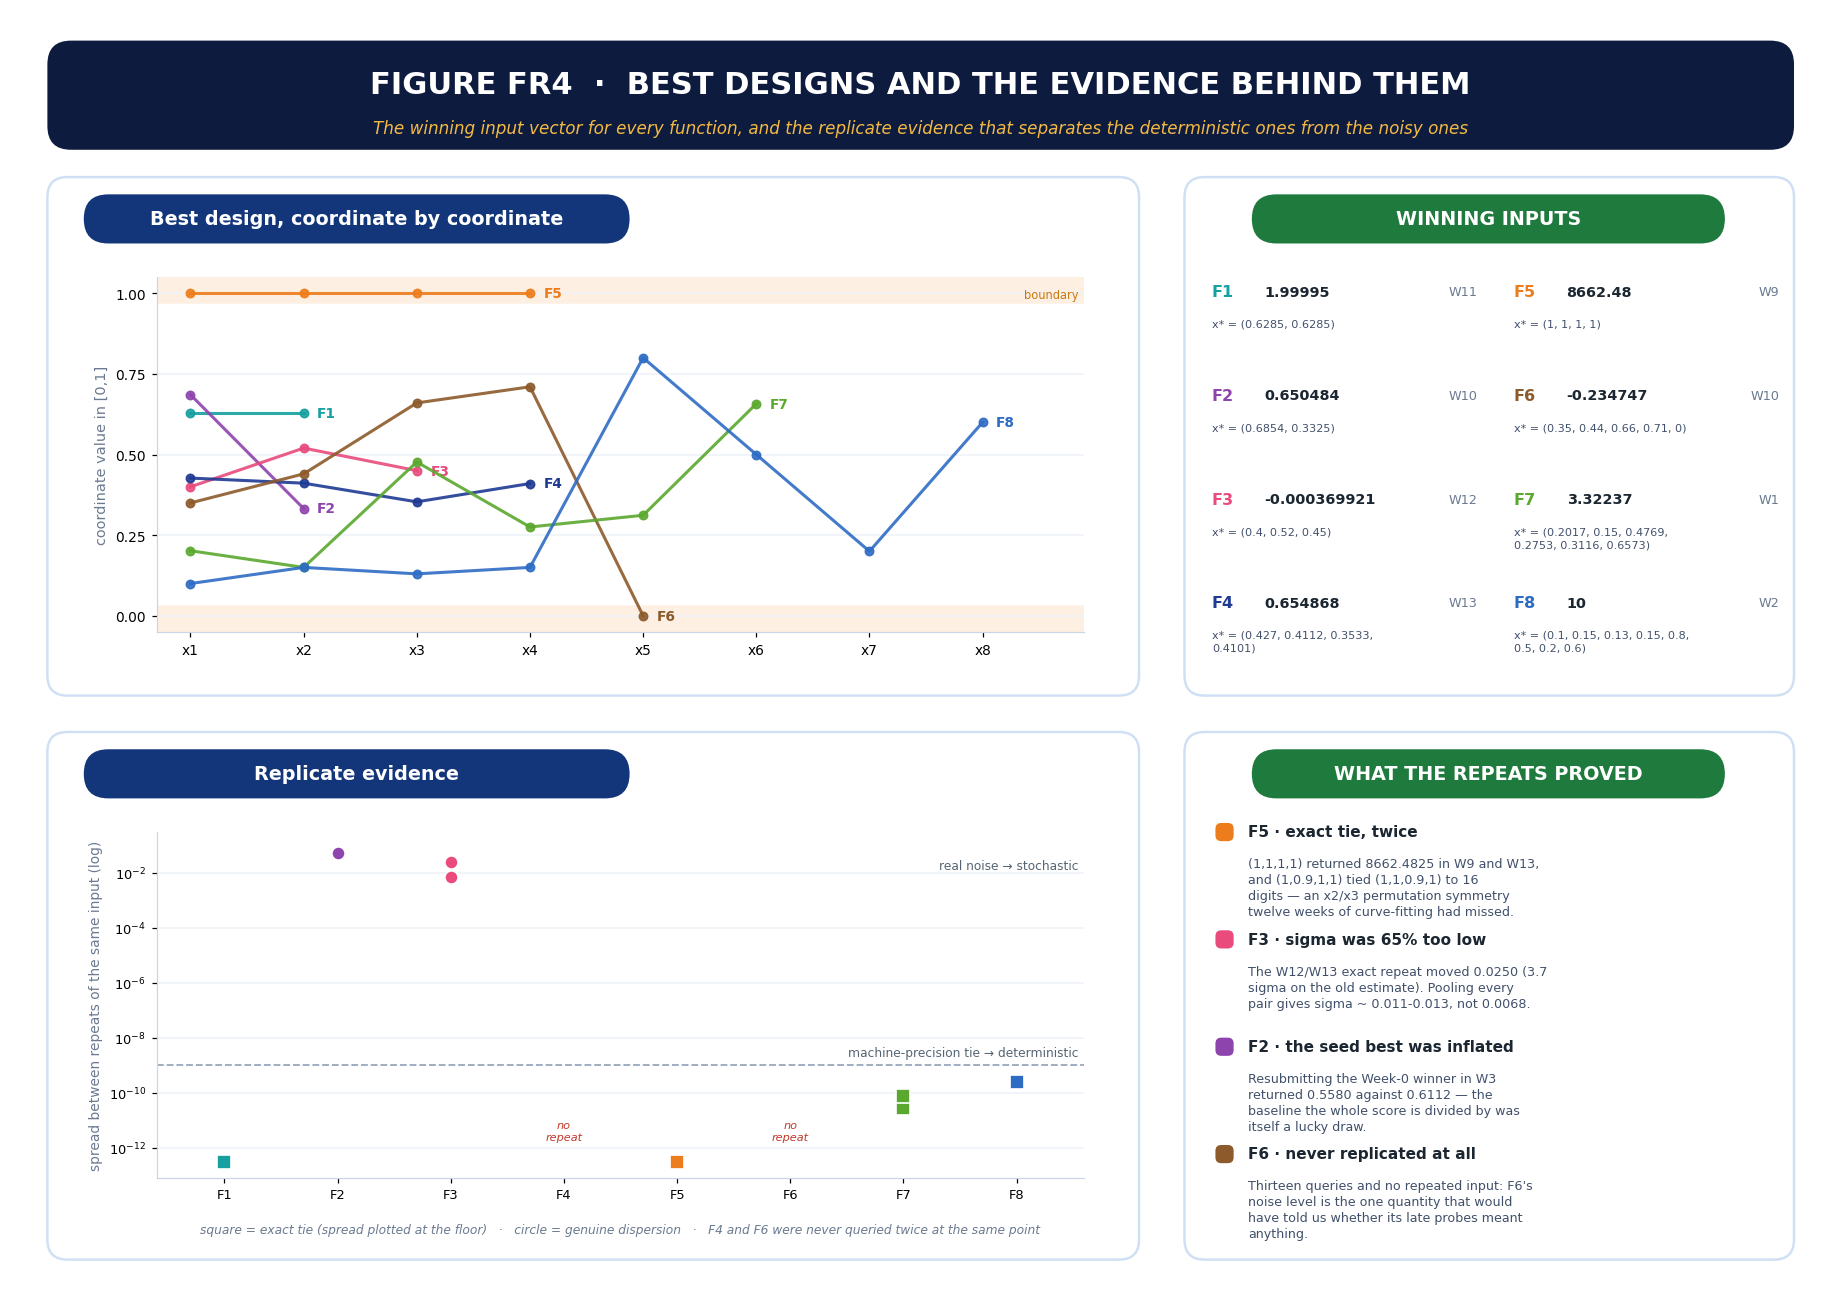

In [14]:
fig_designs_and_evidence(df, tab, save=f"{OUT_DIR}/FR4_best_designs_evidence.png");

## 7 · Figure FR5 — Strengths, deviations and lessons

The retrospective. Three columns: what the strategy got right, where it deviated from good practice and what that cost, and the rules worth carrying into the next campaign.

In [15]:
def fig_lessons(df,tab,save=None):
    W,H=A3; YT=100*H/W
    fig=plt.figure(figsize=A3); fig.patch.set_facecolor("white")
    bg=fig.add_axes([0,0,1,1]); bg.set_xlim(0,100); bg.set_ylim(0,YT); bg.axis("off")
    _ipanel(bg,2,63.0,96,6.0,fc=INFO_NAVY,ec="none",r=1.3)
    bg.text(50,66.6,"FIGURE FR5  ·  WHAT WORKED, WHAT DID NOT, AND WHAT TRANSFERS",ha="center",va="center",
            color="white",fontsize=20,fontweight="bold")
    bg.text(50,64.2,"Every claim below is measured from the 279 observations, not recalled from the weekly notes",
            ha="center",va="center",color="#f4b942",fontsize=11,style="italic")
    cols=[(2.0,"STRENGTHS",INFO_GREEN,"#f2f8f4","#bfe0cd",[
            ("Identify before optimising","F7 and F8 were solved as algebra in weeks 1-2 (residuals 4e-16 and 2e-15), converting two search problems into certainties and freeing every later slot for the hard four."),
            ("Parametric extrapolation on F1","Four consecutive out-of-sample predictions landed within 1.4%; the gap to 2.0 fell 1.84 -> 0.48 -> 4e-04 -> 5e-05."),
            ("Banking made variance an asset","With best-ever retained, F3's high draw was kept permanently and the W13 redraw cost nothing while resetting the noise model."),
            ("Falsification probes","F2's 'two modes', F3's x2 band and F6's x5 rationale were all sampling artifacts, each killed by one probe placed between existing points."),
            ("Structural tests, not just curve fits","Exact 16-digit ties partitioned the eight functions into deterministic and noisy, and exposed F5's x2/x3 symmetry."),
          ]),
          (34.0,"DEVIATIONS",RED,"#fdf3f2","#f0c8c4",[
            ("F5: seven weeks at the wrong end","x1 was never sampled above 0.09 from W2 to W8; the first probe at x1=1 returned 8662 against a 4440 plateau. Monotonicity had been inferred from confounded seed data."),
            ("F6: 94% of the gain came in W3","Ten further queries bought +0.032. By W9 the expected value of an F6 query was visibly near zero, yet the response was smaller steps rather than a long shot or a replicate."),
            ("The F4 ceiling and the OFAT rule","The predicted ceiling of 0.6412 was beaten by 0.0137 by a step that moved all four coordinates. Weeks 9 and 11 took axis-aligned steps and both regressed."),
            ("Noise treated as a nuisance","F3's sigma was 65% low for twelve weeks; F2's sigma was measured in W3 and then ignored for five weeks of probes into a region already known to be weaker."),
            ("F2 misread in the write-up","A region visited four times, mean 0.639 with spread below the noise floor, was recorded as a single lucky draw."),
          ]),
          (66.0,"WHAT TRANSFERS",INFO_BLUE,"#f1f5fc","#c6d6ee",[
            ("Replicate the incumbent first","On a noisy function the observed maximum is an upward-biased order statistic. One repeat of the seed best recalibrates both the noise and the target."),
            ("Bracket every axis before believing a direction","One query at the far end of each suspicious coordinate is the cheapest structural insurance there is. It would have saved four F5 weeks."),
            ("Two ledgers, not one","Score by record reads; decide by pooled means. Conflating them produced both the F3 overconfidence and the F2 misjudgement."),
            ("OFAT diagnoses, correlated steps optimise","Single-variable probes find the live variable; movement along the ridge, not the axis, extracts the value."),
            ("When stalled, raise variance","Best-ever retention makes downside free, so a stalled function's endgame is long shots, not refinement."),
          ])]
    for x0,title,col,fc,ec,items in cols:
        _ipanel(bg,x0,2.0,31.0,59.0,fc=fc,ec=ec,lw=1.6)
        _ipill(bg,x0+15.5,58.8,26,2.9,title,col,fs=13)
        iy=54.5
        for lead,body in items:
            bg.add_patch(FancyBboxPatch((x0+1.4,iy-0.55),1.1,1.1,boxstyle="round,pad=0,rounding_size=0.35",
                         fc=col,ec="none",zorder=4))
            bg.text(x0+3.3,iy,lead,fontsize=10.2,fontweight="bold",color=INK,va="center",zorder=4)
            bg.text(x0+3.3,iy-1.5,textwrap.fill(body,42),fontsize=8.5,color="#41506a",va="top",
                    zorder=4,linespacing=1.35)
            iy-=10.4
    if save: fig.savefig(save,dpi=140,bbox_inches="tight",facecolor="white",pad_inches=0.12)
    return fig

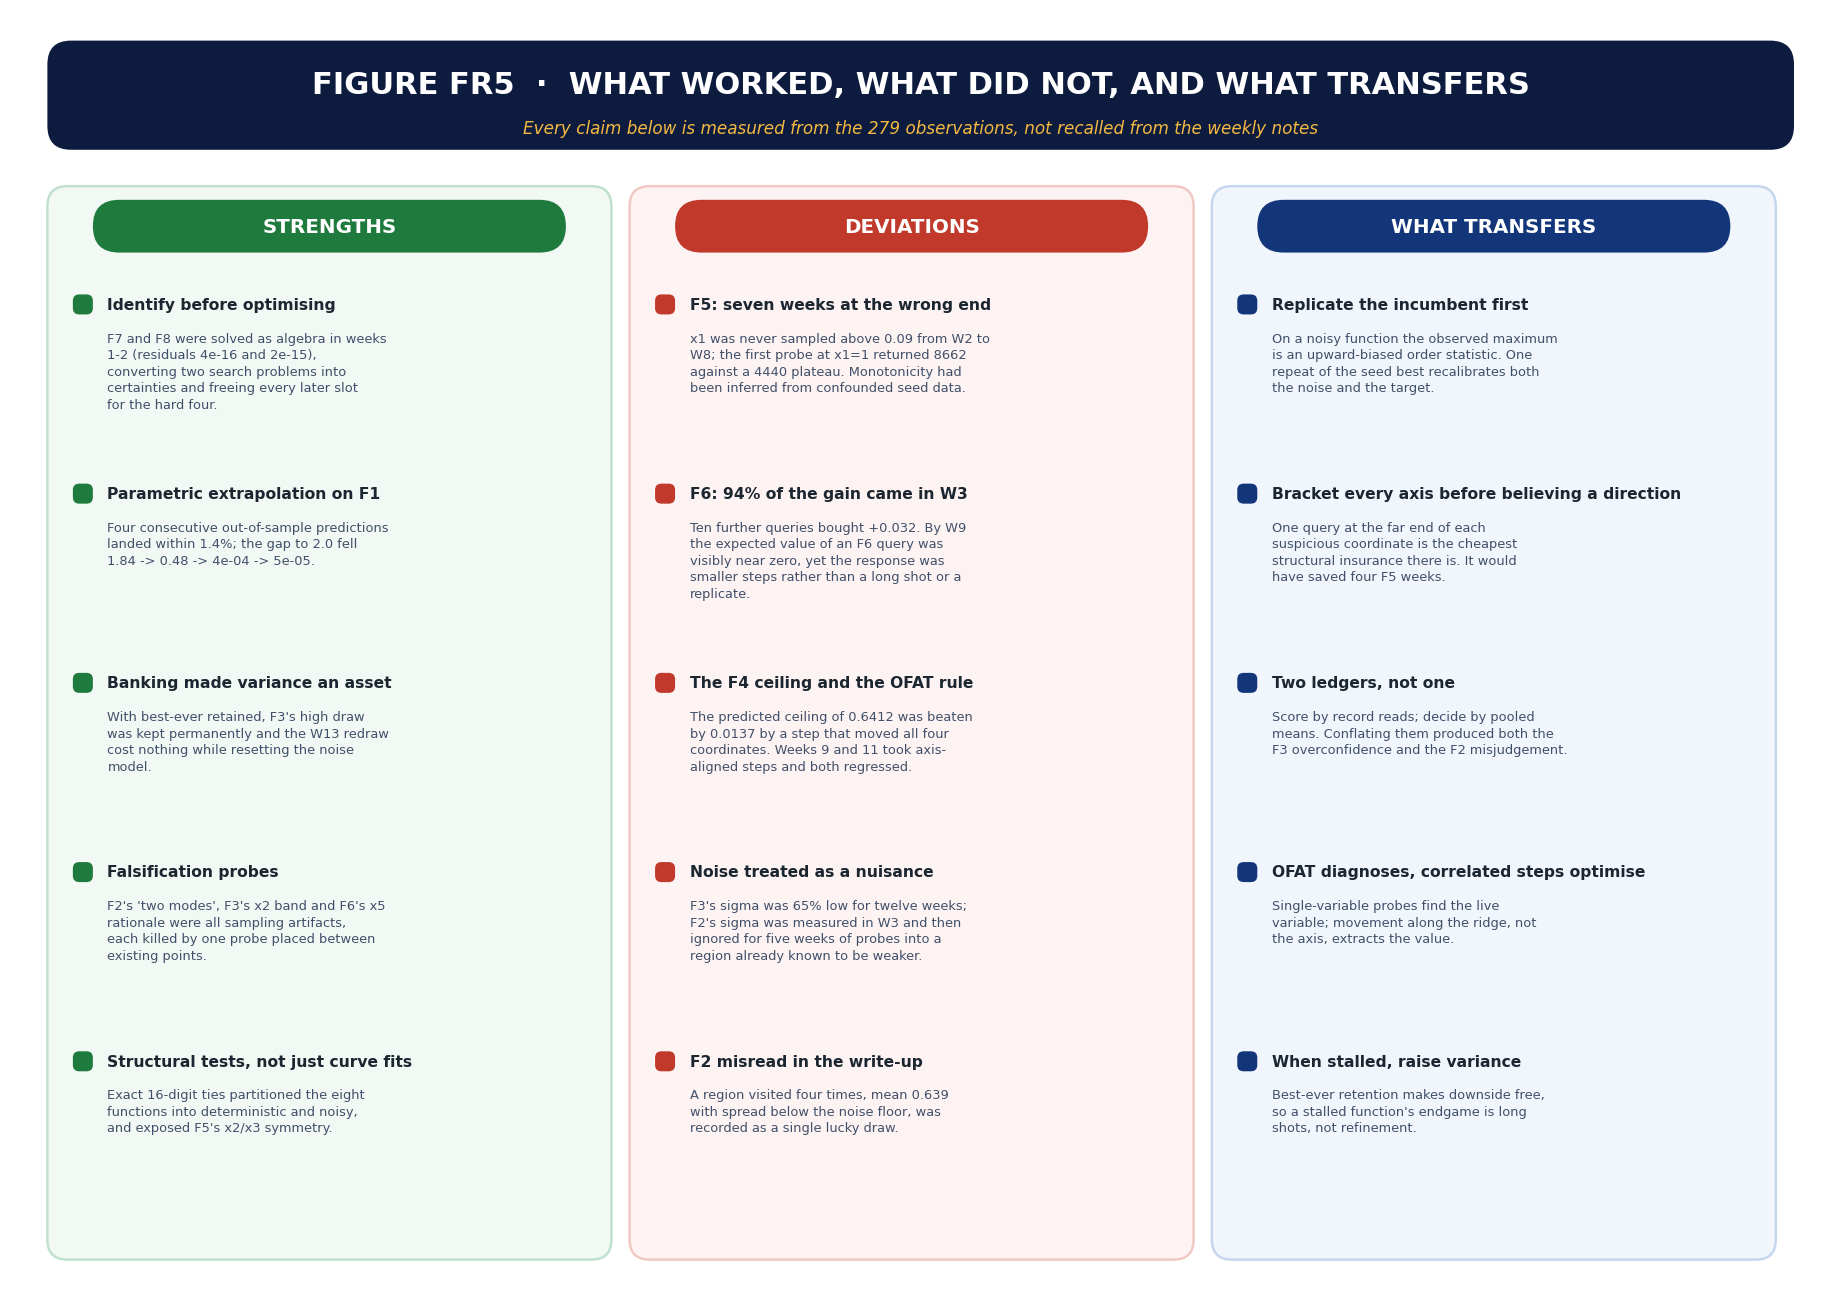

In [16]:
fig_lessons(df, tab, save=f"{OUT_DIR}/FR5_lessons.png");

## 8 · Export the numbers

Writes a tidy one-row-per-function summary next to the figures, so the tables in the written report and the figures can never disagree.

In [17]:
out = tab.copy()
out["best_x"] = out["best_x"].apply(lambda v: "(" + ", ".join(f"{t:.6g}" for t in v) + ")")
out["record_weeks"] = out["record_weeks"].apply(lambda v: " ".join(f"W{w}" for w in v))
cols = ["f","dim","kind","label","n_obs","init_best","best","best_x","best_week",
        "gain","n_records","record_weeks","ceil","ceil_conf","score","score_lo","score_hi"]
out[cols].to_csv(f"{OUT_DIR}/final_campaign_summary.csv", index=False)
print(f"wrote {OUT_DIR}/final_campaign_summary.csv")
scorable = out[np.isfinite(out.score) & (out.f != 2)]
print(f"mean score over the {len(scorable)} functions with defensible ceilings: "
      f"{scorable.score.mean():.4f}")
print(f"F2 scored separately against a speculative ceiling: {out.loc[out.f==2,'score'].iloc[0]:.4f} "
      f"(range {out.loc[out.f==2,'score_lo'].iloc[0]:.2f}-{out.loc[out.f==2,'score_hi'].iloc[0]:.2f})")
display(out[cols])

wrote ./final_campaign_summary.csv
mean score over the 7 functions with defensible ceilings: 0.9955
F2 scored separately against a speculative ceiling: 0.4424 (range 0.28-0.80)


,f,dim,kind,label,n_obs,init_best,best,best_x,best_week,gain,n_records,record_weeks,ceil,ceil_conf,score,score_lo,score_hi
0,1,2,deterministic,log-quadratic crest,23,7.710875e-16,1.999950,"(0.628468, 0.628468)",11,1.999950,7,W2 W3 W5 W8 W9 W10 W11,2.000000,hypothesised,0.999975,0.999975,0.999975
1,2,2,noisy,noisy ridge,23,6.112052e-01,0.650484,"(0.6854, 0.3325)",10,0.039279,2,W9 W10,0.700000,speculative,0.442360,0.283002,0.804988
2,3,3,noisy,noisy plateau,28,-3.483531e-02,-0.000370,"(0.4, 0.52, 0.45)",12,0.034465,4,W1 W9 W10 W12,0.000000,hard cap,0.989381,0.989381,1.000000
3,4,4,deterministic,tilted ridge,43,-4.025542e+00,0.654868,"(0.427, 0.4112, 0.3533, 0.4101)",13,4.680410,6,W1 W3 W6 W7 W10 W13,0.654900,best-ever,0.999993,0.986275,0.999993
4,5,4,deterministic,monotone corner,33,1.088860e+03,8662.482500,"(1, 1, 1, 1)",9,7573.622882,6,W2 W4 W5 W6 W7 W9,8662.482500,corner,1.000000,0.999999,1.000000
5,6,5,noisy,anisotropic basin,33,-7.142649e-01,-0.234747,"(0.35, 0.44, 0.66, 0.71, 0)",10,0.479518,3,W3 W7 W10,-0.224700,low,0.979477,0.897528,1.000000
6,7,6,deterministic,Hartmann-6 (ID'd),43,1.364968e+00,3.322368,"(0.20169, 0.15001, 0.47687, 0.27533, 0.31165, ...",1,1.957400,3,W1 W3 W10,3.322368,analytic,1.000000,1.000000,1.000000
7,8,8,deterministic,separable quadratic,53,9.598482e+00,10.000000,"(0.1, 0.15, 0.13, 0.15, 0.8, 0.5, 0.2, 0.6)",2,0.401518,2,W1 W2,10.000000,analytic,1.000000,1.000000,1.000000


## 9 · Using and adapting this notebook

1. Put **`consolidated_observations.csv`** beside it (or set `BBO_CONSOLIDATED_CSV`). The
   Week-0 rows must be present — they define every baseline.
2. Restart & run all. Five PNGs at A3 landscape and one summary CSV land in `OUT_DIR`.
3. Drop the PNGs straight into the report deck, or print them as A3 handouts.

**Knobs worth touching**
- `CEILINGS` — the only judgement in the notebook. Widen `lo`/`hi` where you are unsure;
  the whiskers in FR1 will say so out loud instead of pretending to a precision you do not have.
- `FUNCTION_META[f]["label"]` / `["story"]` — the short descriptor under each gallery panel.
- `fig_best_design_gallery(..., n=70)` — grid resolution; raise for print, lower for speed.
- `fit_surrogate(..., alpha_noise=...)` — jitter for the GP. Deterministic functions get
  1e-6, noisy ones 1e-2; raise it if a noisy panel looks implausibly bumpy.

**One caveat, stated in the figure itself.** FR3's shading is a surrogate, not the function.
It is drawn to communicate *where our optimum sits relative to what we sampled* — which is
exactly the question a reader of the final report asks, and exactly the question a table of
eight numbers cannot answer. The measured points are always drawn on top so the inference
can be checked against the evidence at a glance.

---

### Where the score actually came from

Two functions (F7, F8) were won by **recognising the function**, not by searching it. One
(F5) was won by **testing an axis we had assumed**. One (F1) was won by **a parametric model
that extrapolated four times in a row**. One (F4) was won by **a step that moved every
coordinate at once**, against the working prescription at the time. F3 was won by **banking a
lucky draw and refusing to redraw**. F2 was won by **abandoning the seed region for one that
reads three sigma better**. Only F6 was not won at all.

Six different mechanisms across eight functions — which is the real lesson of the campaign:
there was no single method, and the budget was best spent on working out *which kind of
problem each function was* before deciding how to attack it.